## ТМО РК1  
Студент: Беликов К. В.  
Группа: ИУ5-66Б  
Вариант №3  

Задача №1.  
Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о  возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

Датасет №3:  
https://www.kaggle.com/carlolepelaars/toy-dataset  

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Подготовка данных

In [2]:
df = pd.read_csv('toy_dataset.csv')
df = df.drop(columns=['Number'])
df.isna().sum()
df = df.dropna()
print(df.columns)

Index(['City', 'Gender', 'Age', 'Income', 'Illness'], dtype='str')


Подготовка к корреляции

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

Корреляционный анализ

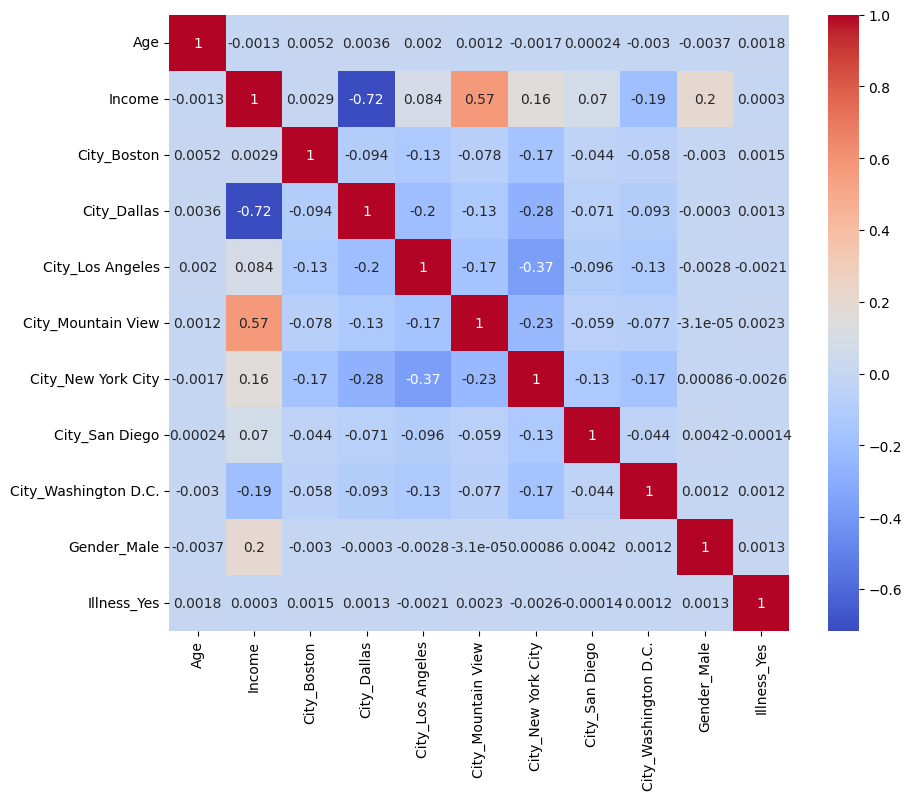

In [4]:
corr = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Проведённый корреляционный анализ показал наличие значимых зависимостей между признаками.  

Наиболее сильная корреляция наблюдается между уровнем дохода (Income) и городом проживания (например, отрицательная корреляция с Dallas и положительная с Mountain  View), что свидетельствует о влиянии географического фактора на доход.  

Показатели Age, Gender и Illness слабо коррелируют со всеми признаками, что говорит о том, что они будут слабо влиять на работу линейной модели, но всё ещё могут быть полезны для нелинейной.  

В целом, построение моделей машинного обучения возможно, однако из-за ограниченного числа сильных зависимостей предпочтительно использовать нелинейные модели. Наибольший вклад в модель будут вносить признаки Income и City.  


**Дополнительное задание:**  
Для студентов группы ИУ5-65Б, ИУ5-66Б, ИУ5И-61Б - для набора данных построить "парные диаграммы".  

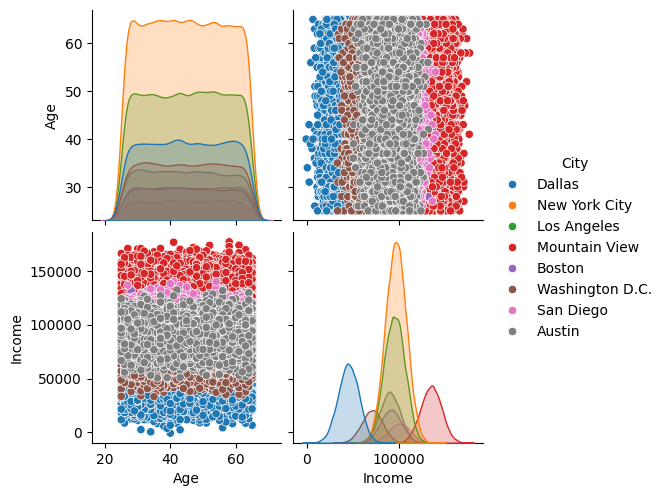

In [5]:
df_num = df.select_dtypes(include=['int', 'float'])
df_num['City'] = df['City']


sns.pairplot(df_num, hue='City')
plt.show()